# Task 3 — Arabic Context to English Canonical Idiom

## Task Overview
This notebook investigates a **cross-lingual idiom prediction task**: given an **Arabic contextual sentence**, the model must predict the corresponding **English canonical idiom**.

This task is more challenging than monolingual context-to-idiom prediction because it requires:
- cross-lingual semantic understanding,
- idiomatic interpretation across languages,
- and precise mapping to a valid canonical English idiom label.

## Experimental Scope
We begin by validating the prepared Task 3 dataset splits and confirming that the task setup is reproducible before training or evaluating any model.

The planned model families are:
1. multilingual retrieval,
2. XLM-R closed-label classification,
3. mT5 cross-lingual generation.

In [5]:
from pathlib import Path
import sys
import warnings
import pandas as pd
import numpy as np

warnings.filterwarnings("ignore")

In [32]:
from pathlib import Path
import sys
import warnings

warnings.filterwarnings("ignore")

def find_project_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "notebooks").exists() and (candidate / "deep_learning").exists():
            return candidate
    raise FileNotFoundError(f"Could not locate IdiomX project root from: {start}")

PROJECT_ROOT = find_project_root(Path.cwd())
TRAINING_DIR = PROJECT_ROOT / "deep_learning" / "training"
TASK3_DATASET_DIR = PROJECT_ROOT / "deep_learning" / "datasets" / "arabic_context_to_idiom"
TASK3_MODEL_DIR = PROJECT_ROOT / "deep_learning" / "models" / "arabic_context_to_idiom"

if str(TRAINING_DIR) not in sys.path:
    sys.path.append(str(TRAINING_DIR))

TASK3_MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("TRAINING_DIR:", TRAINING_DIR)
print("TASK3_DATASET_DIR:", TASK3_DATASET_DIR)
print("TASK3_MODEL_DIR:", TASK3_MODEL_DIR)

PROJECT_ROOT: C:\Users\ayman\Documents\IdiomX\github_idiomX\IdiomX
TRAINING_DIR: C:\Users\ayman\Documents\IdiomX\github_idiomX\IdiomX\deep_learning\training
TASK3_DATASET_DIR: C:\Users\ayman\Documents\IdiomX\github_idiomX\IdiomX\deep_learning\datasets\arabic_context_to_idiom
TASK3_MODEL_DIR: C:\Users\ayman\Documents\IdiomX\github_idiomX\IdiomX\deep_learning\models\arabic_context_to_idiom


### Import Shared Utilities
This step ensures that shared helper functions (e.g., seed control, data loading, validation) are available by explicitly registering the project root in the Python path.

In [28]:
import importlib.util

TOOLS_FILE = PROJECT_ROOT / "deep_learning" / "training" / "tools.py"
print("TOOLS_FILE:", TOOLS_FILE)
print("Exists:", TOOLS_FILE.exists())

if not TOOLS_FILE.exists():
    raise FileNotFoundError(f"tools.py not found at: {TOOLS_FILE}")

spec = importlib.util.spec_from_file_location("idiomx_tools", TOOLS_FILE)
idiomx_tools = importlib.util.module_from_spec(spec)
spec.loader.exec_module(idiomx_tools)

set_seed = idiomx_tools.set_seed
load_csv_checked = idiomx_tools.load_csv_checked
print_basic_df_info = idiomx_tools.print_basic_df_info
ensure_text_pair_columns = idiomx_tools.ensure_text_pair_columns

SEED = 42
set_seed(SEED)

print("tools.py loaded successfully")
print("Seed set to:", SEED)

TOOLS_FILE: C:\Users\ayman\Documents\IdiomX\github_idiomX\IdiomX\deep_learning\training\tools.py
Exists: True
tools.py loaded successfully
Seed set to: 42


### Load Task 3 Dataset Splits
This step loads the prepared train, validation, and test files for Arabic-context-to-idiom prediction using the shared project utilities.

In [15]:
train_df = load_csv_checked(train_path)
val_df = load_csv_checked(val_path)
test_df = load_csv_checked(test_path)

print_basic_df_info("train_df", train_df)
print_basic_df_info("val_df", val_df)
print_basic_df_info("test_df", test_df)

train_df: 55,990 rows × 13 columns
Columns: ['input_text', 'target_text', 'meaning_en', 'meaning_ar', 'example_usage_label', 'is_example_idiom', 'semantic_consistency', 'canonical_semantic_score', 'example_length', 'contains_profanity', 'ambiguity_flag', 'idiom_compositionality_level', 'learner_difficulty']
val_df: 7,024 rows × 13 columns
Columns: ['input_text', 'target_text', 'meaning_en', 'meaning_ar', 'example_usage_label', 'is_example_idiom', 'semantic_consistency', 'canonical_semantic_score', 'example_length', 'contains_profanity', 'ambiguity_flag', 'idiom_compositionality_level', 'learner_difficulty']
test_df: 6,876 rows × 13 columns
Columns: ['input_text', 'target_text', 'meaning_en', 'meaning_ar', 'example_usage_label', 'is_example_idiom', 'semantic_consistency', 'canonical_semantic_score', 'example_length', 'contains_profanity', 'ambiguity_flag', 'idiom_compositionality_level', 'learner_difficulty']


### Supervised Column Validation
We retain only valid `(input_text, target_text)` pairs and ensure there are no missing or invalid entries before proceeding to analysis and modeling.

In [18]:
train_df = ensure_text_pair_columns(
    train_df,
    input_col="input_text",
    target_col="target_text"
)

val_df = ensure_text_pair_columns(
    val_df,
    input_col="input_text",
    target_col="target_text"
)

test_df = ensure_text_pair_columns(
    test_df,
    input_col="input_text",
    target_col="target_text"
)

print("After cleaning:")
print(f"Train size: {len(train_df):,}")
print(f"Validation size: {len(val_df):,}")
print(f"Test size: {len(test_df):,}")

After cleaning:
Train size: 55,990
Validation size: 7,024
Test size: 6,876


### Label Space Analysis
We analyze the distribution of target idioms across splits and verify that validation and test labels are properly represented in the training set.

This step ensures:
- no label leakage issues,
- consistent evaluation conditions,
- and reliable interpretation of model performance.

In [19]:
# ---------------------------------------------------------------------
# Unique idioms per split
# ---------------------------------------------------------------------
train_idioms = set(train_df["target_text"])
val_idioms = set(val_df["target_text"])
test_idioms = set(test_df["target_text"])

print("Unique idioms:")
print(f"Train: {len(train_idioms)}")
print(f"Validation: {len(val_idioms)}")
print(f"Test: {len(test_idioms)}")

# ---------------------------------------------------------------------
# Overlap analysis
# ---------------------------------------------------------------------
val_not_in_train = val_idioms - train_idioms
test_not_in_train = test_idioms - train_idioms

print("\nIdioms NOT seen in training:")
print(f"Validation unseen: {len(val_not_in_train)}")
print(f"Test unseen: {len(test_not_in_train)}")

# ---------------------------------------------------------------------
# Percentage coverage
# ---------------------------------------------------------------------
val_coverage = 1 - (len(val_not_in_train) / len(val_idioms))
test_coverage = 1 - (len(test_not_in_train) / len(test_idioms))

print("\nCoverage (seen in training):")
print(f"Validation coverage: {val_coverage:.3f}")
print(f"Test coverage: {test_coverage:.3f}")

Unique idioms:
Train: 10936
Validation: 1364
Test: 1361

Idioms NOT seen in training:
Validation unseen: 1364
Test unseen: 1361

Coverage (seen in training):
Validation coverage: 0.000
Test coverage: 0.000


### Idiom Frequency Distribution
We analyze how frequently idioms appear in the training set to understand class imbalance, which impacts both retrieval and generative model behavior.

In [20]:
# ---------------------------------------------------------------------
# Idiom frequency in training set
# ---------------------------------------------------------------------
idiom_counts = train_df["target_text"].value_counts()

print("Top 10 most frequent idioms:")
display(idiom_counts.head(10))

print("\nBasic stats:")
print(f"Total idioms: {len(idiom_counts)}")
print(f"Mean frequency: {idiom_counts.mean():.2f}")
print(f"Median frequency: {idiom_counts.median():.2f}")
print(f"Min frequency: {idiom_counts.min()}")
print(f"Max frequency: {idiom_counts.max()}")

Top 10 most frequent idioms:


target_text
you kiss your mother with that mouth    33
may the Force be with you               29
time and tide wait for no man           23
let it be                               20
poverty is a state of mind              19
worship the porcelain god               19
in layman's terms                       18
speak of the devil                      16
Veni, vidi, vici                        16
how are you doing                       16
Name: count, dtype: int64


Basic stats:
Total idioms: 10936
Mean frequency: 5.12
Median frequency: 5.00
Min frequency: 1
Max frequency: 33


### Idiom Frequency Distribution Visualization
We visualize the frequency distribution of idioms in the training set to highlight dataset sparsity and long-tail behavior.

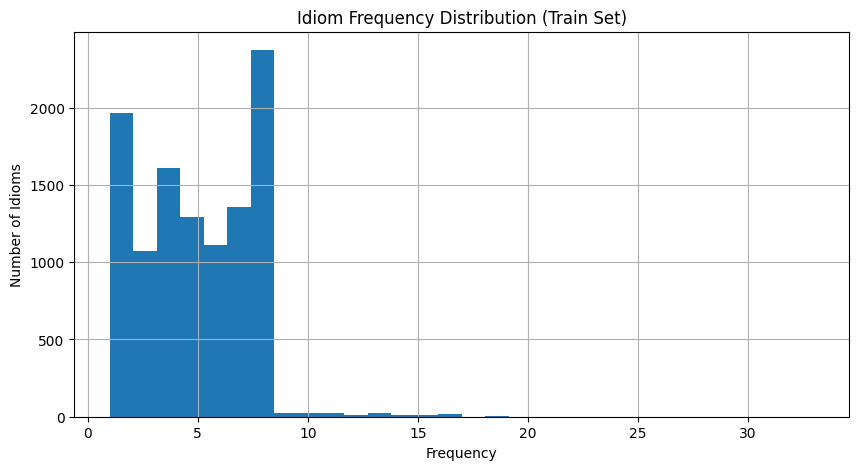

In [21]:
import matplotlib.pyplot as plt

# Sort frequencies
freq_values = idiom_counts.values

plt.figure(figsize=(10, 5))
plt.hist(freq_values, bins=30)

plt.title("Idiom Frequency Distribution (Train Set)")
plt.xlabel("Frequency")
plt.ylabel("Number of Idioms")

plt.grid()
plt.show()

### Final Modeling Strategy

Given the dataset properties, the task is treated as an **open-set cross-lingual generation problem**.

We evaluate three approaches:

1. **Multilingual Retrieval Baseline**
   - Maps Arabic context to closest known idiom via embedding similarity.

2. **mT5 Generative Model**
   - Directly generates the English idiom from Arabic context.

3. **Generation + Canonical Normalization**
   - Generated output is mapped to the closest valid idiom using semantic similarity.

This setup allows us to compare:
- retrieval vs generation,
- and the effect of constrained decoding via normalization.

In [22]:
# ---------------------------------------------------------------------
# Prepare canonical idiom set (from TRAIN only, important!)
# ---------------------------------------------------------------------
canonical_idioms = sorted(train_df["target_text"].unique())

print(f"Number of canonical idioms (train): {len(canonical_idioms)}")

# Preview
print("\nSample idioms:")
for i in canonical_idioms[:10]:
    print("-", i)

Number of canonical idioms (train): 10936

Sample idioms:
- $100 hamburger
- 'ark at ee
- 'fraid so
- 'tis the season
- 110 proof
- 12-ounce curls
- 23 skidoo
- 800-pound gorilla
- A faint heart never won a fair lady
- A little learning is a dangerous thing


### Multilingual Retrieval Baseline

We implement a retrieval-based baseline using multilingual sentence embeddings.

Approach:
- Encode Arabic input text
- Encode canonical idioms (English)
- Compute cosine similarity
- Predict the closest idiom (Top-1)

This serves as a strong non-generative baseline for comparison.

In [23]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm

# ---------------------------------------------------------------------
# Load multilingual embedding model
# ---------------------------------------------------------------------
retrieval_model = SentenceTransformer(
    "sentence-transformers/paraphrase-multilingual-mpnet-base-v2"
)

print("Model loaded")

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/723 [00:00<?, ?B/s]

...

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded


### Experiment Output Structure
Task 3 training and evaluation will be executed through reusable Python scripts.  
The notebook will act as the orchestration layer and will read results, figures, and saved predictions from the project output directories.

In [24]:
TASK3_MODEL_DIR = PROJECT_ROOT / "deep_learning" / "models" / "arabic_context_to_idiom"
TASK3_FIGURE_DIR = PROJECT_ROOT / "figures" / "arabic_context_to_idiom"

TASK3_MODEL_DIR.mkdir(parents=True, exist_ok=True)
TASK3_FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("TASK3_MODEL_DIR:", TASK3_MODEL_DIR)
print("TASK3_FIGURE_DIR:", TASK3_FIGURE_DIR)

TASK3_MODEL_DIR: C:\Users\ayman\Documents\IdiomX\github_idiomX\IdiomX\deep_learning\models\arabic_context_to_idiom
TASK3_FIGURE_DIR: C:\Users\ayman\Documents\IdiomX\github_idiomX\IdiomX\figures\arabic_context_to_idiom


In [25]:
import subprocess
import sys
from pathlib import Path

cmd = [
    sys.executable,
    str(PROJECT_ROOT / "deep_learning" / "training" / "train_arabic_context_to_idiom_retrieval.py"),
    "--batch_size", "64",
    "--top_k_max", "5",
    "--mrr_cutoff", "100",
    "--bank_mode", "auto",
]

result = subprocess.run(cmd, cwd=PROJECT_ROOT, check=True)
print("Retrieval experiment finished successfully.")

Retrieval experiment finished successfully.


In [26]:
import pandas as pd

retrieval_output_dir = PROJECT_ROOT / "deep_learning" / "models" / "arabic_context_to_idiom" / "retrieval"

val_metrics = pd.read_csv(retrieval_output_dir / "validation_metrics.csv")
test_metrics = pd.read_csv(retrieval_output_dir / "test_metrics.csv")

display(val_metrics)
display(test_metrics)

,num_samples,num_bank_candidates,top1_accuracy,top3_accuracy,top5_accuracy,mrr_at_cutoff,mean_top1_similarity,gold_found_rate_within_mrr_cutoff
0,7024,15009,0.204727,0.287728,0.330438,0.251061,0.60797,0.590831


,num_samples,num_bank_candidates,top1_accuracy,top3_accuracy,top5_accuracy,mrr_at_cutoff,mean_top1_similarity,gold_found_rate_within_mrr_cutoff
0,6876,15009,0.202734,0.29014,0.330425,0.25024,0.607004,0.605003


In [30]:
# ------------------------------------------------------------
# Ensure training directory is in sys.path (for tools.py)
# ------------------------------------------------------------
TRAINING_DIR = Path(__file__).resolve().parent

if str(TRAINING_DIR) not in sys.path:
    sys.path.insert(0, str(TRAINING_DIR))

# ------------------------------------------------------------
# Local shared tools
# ------------------------------------------------------------
from tools import (
    set_seed,
    load_csv_checked,
    ensure_text_pair_columns,
    ensure_dir,
    compute_topk_accuracy,
    compute_mrr,
)

NameError: name '__file__' is not defined

In [33]:
import importlib

import train_arabic_context_to_idiom_retrieval as retrieval_module
importlib.reload(retrieval_module)

print("Retrieval module loaded successfully")

Retrieval module loaded successfully


### Run Retrieval Baseline

We execute the Task 3 retrieval baseline using the imported training module.  
This follows the same execution pattern used in previous IdiomX experiments.

In [35]:
available_names = [name for name in dir(retrieval_module) if not name.startswith("_")]
print(available_names)

['CACHE_DIR', 'DATASET_DIR', 'Dict', 'IDIOM_BANK_PATH', 'List', 'OUTPUT_DIR', 'PLOT_DIR', 'PRED_DIR', 'PROJECT_ROOT', 'Path', 'SentenceTransformer', 'TEST_PATH', 'TRAIN_PATH', 'Tuple', 'VAL_PATH', 'annotations', 'argparse', 'build_bank_from_idiom_bank', 'build_bank_from_train', 'build_candidate_bank', 'compute_mrr', 'compute_topk_accuracy', 'cosine_similarity', 'encode_or_load_bank', 'ensure_dir', 'ensure_text_pair_columns', 'evaluate_split', 'find_project_root', 'get_cache_paths', 'json', 'load_csv_checked', 'load_splits', 'main', 'np', 'parse_args', 'pd', 'plt', 'reciprocal_rank', 'run_experiment', 'save_metrics_bar_plot', 'save_rank_histogram', 'save_split_outputs', 'set_seed']


In [36]:
class RetrievalArgs:
    model_name = "sentence-transformers/paraphrase-multilingual-mpnet-base-v2"
    batch_size = 64
    top_k_max = 5
    mrr_cutoff = 100
    bank_mode = "auto"
    seed = 42
    rebuild_cache = False

results_retrieval = retrieval_module.run_experiment(RetrievalArgs())

print("\nValidation Metrics:")
print(results_retrieval["validation"])

print("\nTest Metrics:")
print(results_retrieval["test"])

Task 3 Retrieval Baseline
PROJECT_ROOT: C:\Users\ayman\Documents\IdiomX\github_idiomX\IdiomX
DATASET_DIR: C:\Users\ayman\Documents\IdiomX\github_idiomX\IdiomX\deep_learning\datasets\arabic_context_to_idiom
OUTPUT_DIR: C:\Users\ayman\Documents\IdiomX\github_idiomX\IdiomX\deep_learning\models\arabic_context_to_idiom\retrieval

Loading dataset splits...
Train size: 55,990
Validation size: 7,024
Test size: 6,876

Building candidate bank...
Bank source: idiom_bank
Bank size: 15,009

Loading embedding model...
Model: sentence-transformers/paraphrase-multilingual-mpnet-base-v2

Loading cached bank embeddings...
Cache hit.

Evaluating validation split...

Encoding split inputs...


Batches:   0%|          | 0/110 [00:00<?, ?it/s]

Computing cosine similarities...

Saved validation predictions to: C:\Users\ayman\Documents\IdiomX\github_idiomX\IdiomX\deep_learning\models\arabic_context_to_idiom\retrieval\predictions\validation_predictions.csv
Saved validation metrics CSV to: C:\Users\ayman\Documents\IdiomX\github_idiomX\IdiomX\deep_learning\models\arabic_context_to_idiom\retrieval\validation_metrics.csv
Saved validation metrics JSON to: C:\Users\ayman\Documents\IdiomX\github_idiomX\IdiomX\deep_learning\models\arabic_context_to_idiom\retrieval\validation_metrics.json

Evaluating test split...

Encoding split inputs...


Batches:   0%|          | 0/108 [00:00<?, ?it/s]

Computing cosine similarities...

Saved test predictions to: C:\Users\ayman\Documents\IdiomX\github_idiomX\IdiomX\deep_learning\models\arabic_context_to_idiom\retrieval\predictions\test_predictions.csv
Saved test metrics CSV to: C:\Users\ayman\Documents\IdiomX\github_idiomX\IdiomX\deep_learning\models\arabic_context_to_idiom\retrieval\test_metrics.csv
Saved test metrics JSON to: C:\Users\ayman\Documents\IdiomX\github_idiomX\IdiomX\deep_learning\models\arabic_context_to_idiom\retrieval\test_metrics.json

Final Summary
{
  "validation": {
    "num_samples": 7024,
    "num_bank_candidates": 15009,
    "top1_accuracy": 0.20472665148063782,
    "top3_accuracy": 0.28772779043280183,
    "top5_accuracy": 0.3304384965831435,
    "mrr_at_cutoff": 0.2510606492027336,
    "mean_top1_similarity": 0.6079703193616147,
    "gold_found_rate_within_mrr_cutoff": 0.5908314350797267
  },
  "test": {
    "num_samples": 6876,
    "num_bank_candidates": 15009,
    "top1_accuracy": 0.20273414776032578,
    "t

In [42]:
import train_arabic_context_to_idiom_mt5 as mt5_module
import importlib
importlib.reload(mt5_module)

mt5_module.run_arabic_context_mt5()

Running mT5 model for Task 3
Train size: 55990
Val size: 7024
Test size: 6876

Loading mT5 model...
Model loaded

Tokenizing training data...
Tokenization complete

Dataset objects created
Train dataset size: 55990
Validation dataset size: 7024


{'status': 'initialized'}

In [44]:
!pip install -U transformers

Defaulting to user installation because normal site-packages is not writeable
  Using cached huggingface_hub-1.7.2-py3-none-any.whl.metadata (13 kB)
  Using cached tokenizers-0.22.2-cp39-abi3-win_amd64.whl.metadata (7.4 kB)
   ---------------------------------------- 0.0/10.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.7 MB ? eta -:--:--
    --------------------------------------- 0.3/10.7 MB ? eta -:--:--
   ---- ----------------------------------- 1.3/10.7 MB 3.5 MB/s eta 0:00:03
   ------------- -------------------------- 3.7/10.7 MB 7.0 MB/s eta 0:00:01
   ------------------ --------------------- 5.0/10.7 MB 6.7 MB/s eta 0:00:01
   ------------------- -------------------- 5.2/10.7 MB 5.4 MB/s eta 0:00:02
   --------------------------- ------------ 7.3/10.7 MB 6.5 MB/s eta 0:00:01
   ---------------------------------------- 10.7/10.7 MB 7.9 MB/s  0:00:01
   ---------------------------------------- 0.0/618.0 kB ? eta -:--:--
   --------------------------------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langchain-huggingface 0.1.2 requires langchain-core<0.4.0,>=0.3.15, which is not installed.
langchain-huggingface 0.1.2 requires sentence-transformers>=2.6.0, which is not installed.
tts 0.22.0 requires pandas<2.0,>=1.4, but you have pandas 3.0.1 which is incompatible.


In [46]:
import importlib
importlib.reload(mt5_module)

results_mt5 = mt5_module.run_arabic_context_mt5(
    train_csv=TASK3_DATASET_DIR / "train.csv",
    val_csv=TASK3_DATASET_DIR / "validation.csv",
    test_csv=TASK3_DATASET_DIR / "test.csv",
    output_dir=TASK3_MODEL_DIR / "mt5"
)

Running mT5 model for Task 3
Train size: 55990
Val size: 7024
Test size: 6876

Loading mT5 model...
Model loaded

Tokenizing...
Tokenization complete

Starting training...


Step,Training Loss
100,0.000000
200,0.000000
300,0.000000
400,0.000000
500,0.000000
600,0.000000
700,0.000000
800,0.000000
900,0.000000
1000,0.000000


Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.



Evaluating...
Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "C:\ProgramData\anaconda3\envs\pytorch_GPU\lib\site-packages\IPython\core\interactiveshell.py", line 3526, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "C:\Users\ayman\AppData\Local\Temp\ipykernel_78304\2838232499.py", line 4, in <module>
    results_mt5 = mt5_module.run_arabic_context_mt5(
  File "C:\Users\ayman\Documents\IdiomX\github_idiomX\IdiomX\deep_learning\training\train_arabic_context_to_idiom_mt5.py", line 184, in run_arabic_context_mt5
    val_preds = generate_predictions(val_df)
  File "C:\Users\ayman\Documents\IdiomX\github_idiomX\IdiomX\deep_learning\training\train_arabic_context_to_idiom_mt5.py", line 180, in generate_predictions
    pred = tokenizer.decode(outputs[0], skip_special_tokens=True)
  File "C:\Users\ayman\AppData\Roaming\Python\Python39\site-packages\transformers\tokenization_utils_base.py", line 4064, in decode
    return self._decode(
  File "C:\Users\ayman\AppData\Roaming\Python\Python39